In [3]:
import pandas as pd
import seaborn as sns


# Función carga tablas de datos
def cargar_datos(path_sin_libranza, path_con_libranza, path_deterioro):
    nuevo_sin_libranza = pd.read_csv(path_sin_libranza)
    nuevo_con_libranza = pd.read_csv(path_con_libranza)

    viejo_sin_libranza = pd.read_excel(
        path_deterioro, sheet_name="PE Consumo sin libranza", header=0
    )
    viejo_sin_libranza = viejo_sin_libranza.iloc[:-1]

    viejo_con_libranza = pd.read_excel(
        path_deterioro, sheet_name="PE Consumo con libranza", header=0
    )
    viejo_con_libranza = viejo_con_libranza.iloc[:-1]

    calificacion_viejo = pd.read_excel(
        path_deterioro,
        sheet_name="Calificación",
        header=0,
    )
    return (
        nuevo_sin_libranza,
        nuevo_con_libranza,
        viejo_sin_libranza,
        viejo_con_libranza,
        calificacion_viejo,
    )

In [4]:
# Cargar tablas de datos junio 2022
(
    nuevo_sin_libranza,
    nuevo_con_libranza,
    viejo_sin_libranza,
    viejo_con_libranza,
    calificacion_viejo,
) = cargar_datos(
    "PE_sin_libranza.csv",
    "PE_con_libranza.csv",
    "DETERIORO-SUPERSOLIDARIA_2025-09.xlsx",
)

In [5]:
# Función retorna dataframe de comparación crédito sin libranza


def sin_libranza(nuevo_sin_libranza, viejo_sin_libranza, calificacion_viejo):
    comp_sin_libranza = pd.merge(
        nuevo_sin_libranza[
            [
                "NroCredito",
                "PE",
                "PI",
                "VEA",
                "PDI",
                "Calif.modelo",
                "Calif.homologada",
                "Calif.final",
            ]
        ],
        viejo_sin_libranza[["N.Credito", "PE", "Calificacion", "PI", "VEA", "PDI"]],
        left_on="NroCredito",
        right_on="N.Credito",
        suffixes=("_nuevo", "_viejo"),
        how="inner",
    )

    comp_sin_libranza = comp_sin_libranza.drop(
        columns=["N.Credito", "VEA_nuevo", "VEA_viejo"]
    )

    comp_sin_libranza = comp_sin_libranza.merge(
        calificacion_viejo[
            ["N.Credito", "Calif.modelo", "Calif.homologada", "Calif.final"]
        ],
        left_on="NroCredito",
        right_on="N.Credito",
        how="left",
        suffixes=("_nuevo", "_viejo"),
    )

    comp_sin_libranza = comp_sin_libranza.drop(columns=["N.Credito"])
    return comp_sin_libranza


# Función retorna dataframe de comparación crédito con libranza


def con_libranza(nuevo_con_libranza, viejo_con_libranza, calificacion_viejo):
    comp_con_libranza = pd.merge(
        nuevo_con_libranza[
            [
                "NroCredito",
                "PE",
                "PI",
                "VEA",
                "PDI",
                "Calif.modelo",
                "Calif.homologada",
                "Calif.final",
            ]
        ],
        viejo_con_libranza[["N.Credito", "PE", "Calificacion", "PI", "VEA", "PDI"]],
        left_on="NroCredito",
        right_on="N.Credito",
        suffixes=("_nuevo", "_viejo"),
        how="inner",
    )
    comp_con_libranza = comp_con_libranza.drop(
        columns=["N.Credito", "VEA_nuevo", "VEA_viejo"]
    )

    comp_con_libranza = comp_con_libranza.merge(
        calificacion_viejo[
            ["N.Credito", "Calif.modelo", "Calif.homologada", "Calif.final"]
        ],
        left_on="NroCredito",
        right_on="N.Credito",
        how="left",
        suffixes=("_nuevo", "_viejo"),
    )
    comp_con_libranza = comp_con_libranza.drop(columns=["N.Credito"])
    return comp_con_libranza

In [6]:
comp_con_libranza = con_libranza(
    nuevo_con_libranza, viejo_con_libranza, calificacion_viejo
)
comp_sin_libranza = sin_libranza(
    nuevo_sin_libranza, viejo_sin_libranza, calificacion_viejo
)

In [7]:
comp_con_libranza[["PE_nuevo", "PE_viejo"]].describe()

,PE_nuevo,PE_viejo
count,7.370000e+03,7.370000e+03
mean,2.924625e+04,2.153942e+04
std,2.471869e+05,4.031212e+04
min,2.750625e+01,2.750625e+01
25%,5.390170e+03,5.377366e+03
50%,1.217226e+04,1.211215e+04
75%,2.636891e+04,2.612865e+04
max,1.766134e+07,1.214196e+06


In [8]:
comp_con_libranza[["PE_nuevo", "PE_viejo"]].sum()

PE_nuevo    2.155448e+08
PE_viejo    1.587455e+08
dtype: float64

<Axes: xlabel='PE_viejo', ylabel='PE_nuevo'>

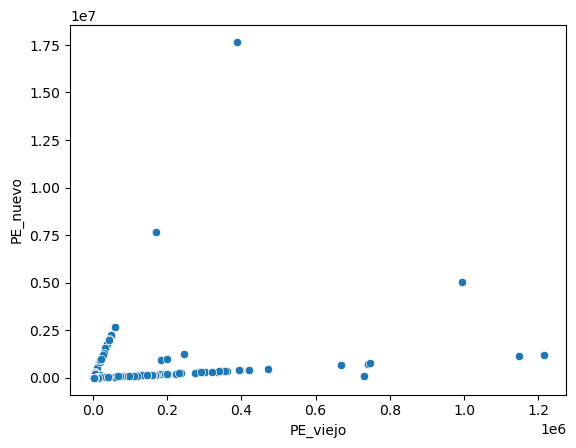

In [9]:
# scatter PE_nuevo vs PE_viejo

sns.scatterplot(
    data=comp_con_libranza,
    x="PE_viejo",
    y="PE_nuevo",
)

In [10]:
pd.crosstab(
    comp_con_libranza["Calif.final_viejo"], comp_con_libranza["Calif.final_nuevo"]
)

Calif.final_nuevo,A,B,C,D,E
Calif.final_viejo,,,,,
A,7115,0,0,5,26
B,0,154,0,2,0
C,0,1,12,7,1
D,0,1,34,8,4


In [11]:
comp_sin_libranza[["PE_nuevo", "PE_viejo"]].describe()

,PE_nuevo,PE_viejo
count,8.533000e+03,8.533000e+03
mean,3.343016e+05,2.965692e+05
std,2.838334e+06,2.374830e+06
min,1.991250e+00,1.991250e+00
25%,1.942493e+04,1.949685e+04
50%,5.415834e+04,5.480740e+04
75%,1.342429e+05,1.374913e+05
max,1.018149e+08,1.567500e+08


In [12]:
comp_sin_libranza[["PE_nuevo", "PE_viejo"]].sum()

PE_nuevo    2.852595e+09
PE_viejo    2.530625e+09
dtype: float64

<Axes: xlabel='PE_viejo', ylabel='PE_nuevo'>

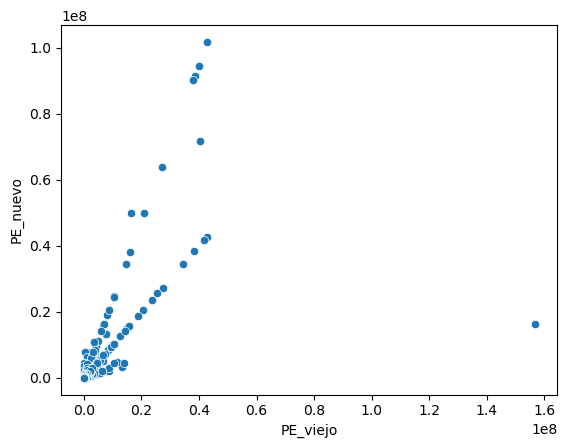

In [13]:
# scatter PE_nuevo vs PE_viejo

sns.scatterplot(
    data=comp_sin_libranza,
    x="PE_viejo",
    y="PE_nuevo",
)

In [14]:
pd.crosstab(
    comp_sin_libranza["Calif.final_viejo"], comp_sin_libranza["Calif.final_nuevo"]
)

Calif.final_nuevo,A,B,C,D,E
Calif.final_viejo,,,,,
A,7038,1,2,4,7
B,24,632,0,4,2
C,0,85,325,198,62
D,0,0,52,9,13
E,0,0,75,0,0
